# Transfer Learning with Pretrained CNNs


Dataset
- Oxford 102 Flowers dataset — https://www.robots.ox.ac.uk/~vgg/data/flowers/102/  

### GitHub
> **Repository:** https://github.com/gaurey/cnn-transfer-learning

Gaurav 24176174


## 0. Install dependencies


In [1]:

import subprocess, sys
packages = ['torch', 'torchvision', 'matplotlib', 'numpy', 'Pillow', 'tqdm', 'scipy']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + packages)


0

## 1. Imports & reproducibility


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import Flowers102
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from tqdm.auto import tqdm
import copy, os, time


SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

# Accessibility: using a colourblind-safe palette throughout
PALETTE = {'A_train': '#E69F00',
    'A_val':   '#E69F00',
    'B_train': '#0072B2',
    'B_val':   '#0072B2',
    'C_train': '#009E73',
    'C_val':   '#009E73'}


Using device: cuda


## 2. Load and Transform Dataset



In [3]:
DATA_DIR   = './data'
BATCH_SIZE = 32
NUM_WORKERS = 2


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([transforms.RandomResizedCrop(224),transforms.RandomHorizontalFlip(),transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                  transforms.ToTensor(),transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

val_transform = transforms.Compose([transforms.Resize(256),transforms.CenterCrop(224),transforms.ToTensor(),transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])


train_dataset = Flowers102(root=DATA_DIR, split='train',transform=train_transform, download=True)
val_dataset   = Flowers102(root=DATA_DIR, split='val',transform=val_transform,   download=True)
test_dataset  = Flowers102(root=DATA_DIR, split='test',transform=val_transform,   download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,shuffle=False, num_workers=NUM_WORKERS)

NUM_CLASSES = 102
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')


100%|██████████| 345M/345M [00:20<00:00, 16.9MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.02MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 38.6MB/s]


Train: 1020 | Val: 1020 | Test: 6149


### 2a. Visualise sample images


> **Accessibility note:** All figures use colourblind-safe palettes (Okabe-Ito).



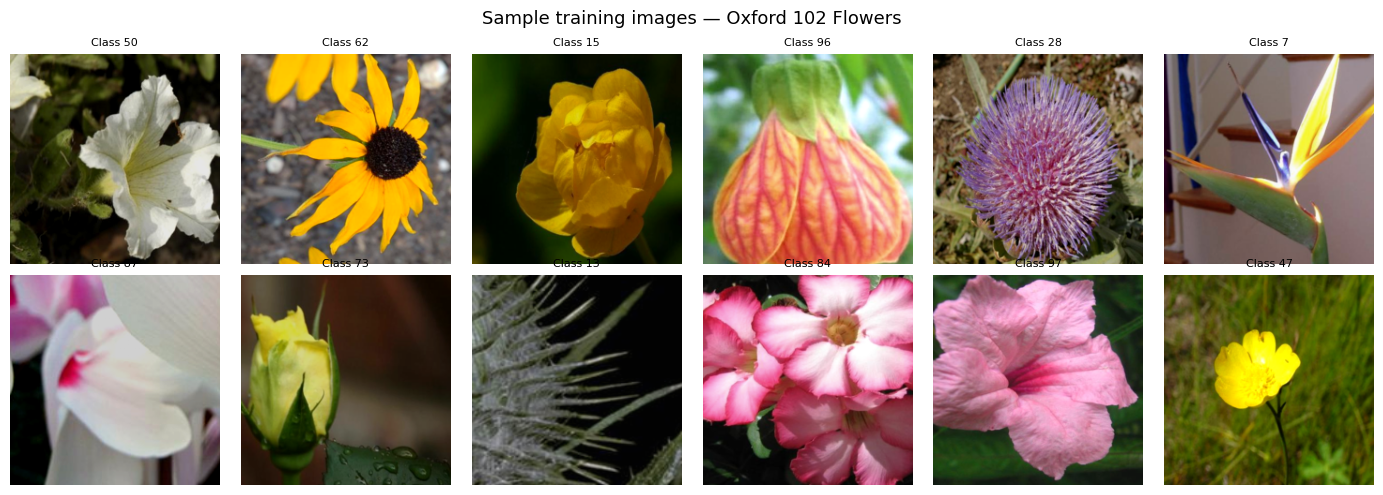

In [4]:
def denormalise(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Sample training images — Oxford 102 Flowers', fontsize=13)
for ax, img, lbl in zip(axes.flatten(), images[:12], labels[:12]):
    ax.imshow(denormalise(img).permute(1, 2, 0))
    ax.set_title(f'Class {lbl.item()}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('fig_samples.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. Model — ResNet-18

In [5]:
def build_model(strategy: str, num_classes: int = NUM_CLASSES):
    """
    Parameters
    strategy : A,B,C
    A = Feature Extraction  (freeze all pretrained layers)
    B = Partial Fine-tuning (unfreeze layer4 + head)
    C = Full Fine-tuning    (unfreeze everything)
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)


    for param in model.parameters():
        param.requires_grad = False


    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(p=0.3),nn.Linear(in_features, num_classes))


    if strategy == 'B':
        for param in model.layer4.parameters():
            param.requires_grad = True

    elif strategy == 'C':
        for param in model.parameters():
            param.requires_grad = True


    for param in model.fc.parameters():
        param.requires_grad = True

    return model.to(DEVICE)


for strat in ['A', 'B', 'C']:
    m = build_model(strat)
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'Strategy {strat}: {trainable:,} / {total:,} parameters trainable')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


Strategy A: 52,326 / 11,228,838 parameters trainable
Strategy B: 8,446,054 / 11,228,838 parameters trainable
Strategy C: 11,228,838 / 11,228,838 parameters trainable


## 4. Optimisers — differential learning rates



In [6]:
def build_optimizer(model, strategy: str):
    if strategy in ('A', 'B'):
        trainable = [p for p in model.parameters() if p.requires_grad]
        return optim.Adam(trainable, lr=1e-3)


    return optim.Adam([
        {'params': model.fc.parameters(),     'lr': 1e-3},{'params': model.layer4.parameters(), 'lr': 1e-4},{'params': list(model.layer3.parameters()) +
        list(model.layer2.parameters()) +list(model.layer1.parameters()), 'lr': 1e-5}])


## 5. Training loop


In [7]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, correct, n = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            n          += images.size(0)

    return total_loss / n, correct / n


def train_model(strategy: str, num_epochs: int = 20):
    print(f'\n{'='*50}')
    print(f'  Strategy {strategy}')
    print(f'{'='*50}')

    model     = build_model(strategy)
    optimizer = build_optimizer(model, strategy)
    scheduler = StepLR(optimizer, step_size=7, gamma=0.1)
    criterion = nn.CrossEntropyLoss()

    history = {'train_acc': [], 'val_acc': [],
               'train_loss': [], 'val_loss': []}
    best_acc    = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in tqdm(range(num_epochs), desc=f'Strategy {strategy}'):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion)
        scheduler.step()

        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)

        if vl_acc > best_acc:
            best_acc     = vl_acc
            best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    print(f'  Best val accuracy: {best_acc:.4f}')
    return model, history


## 6. Run all three strategies



In [8]:
NUM_EPOCHS = 20

results = {}
for strategy in ['A', 'B', 'C']:
    model, history = train_model(strategy, num_epochs=NUM_EPOCHS)
    results[strategy] = {'model': model, 'history': history}



  Strategy A


Strategy A:   0%|          | 0/20 [00:00<?, ?it/s]

  Best val accuracy: 0.8235

  Strategy B


Strategy B:   0%|          | 0/20 [00:00<?, ?it/s]

  Best val accuracy: 0.9176

  Strategy C


Strategy C:   0%|          | 0/20 [00:00<?, ?it/s]

  Best val accuracy: 0.9216


## 7. Figure 2 — Learning curves

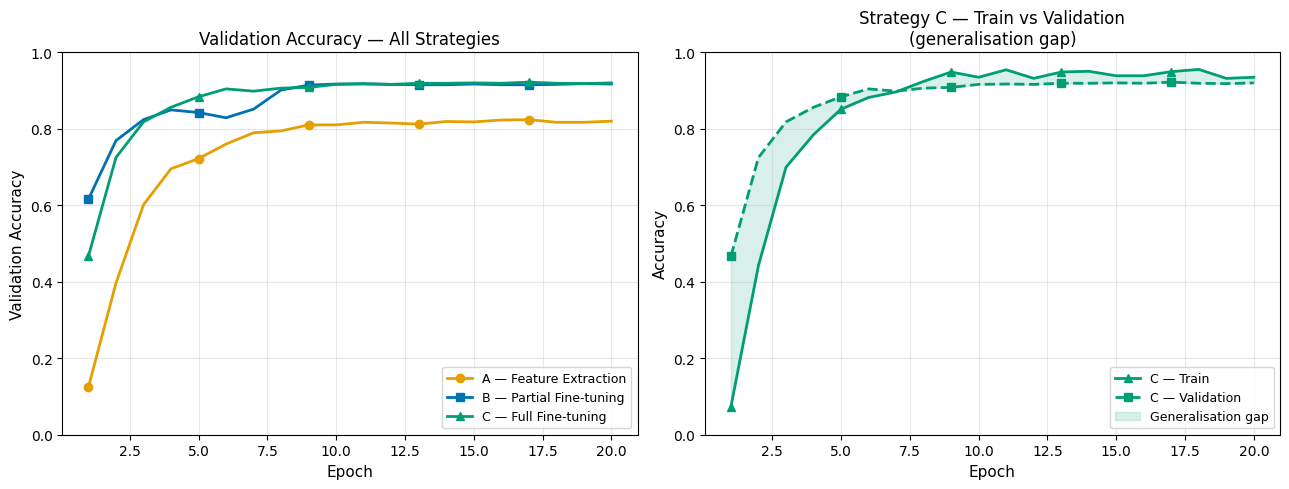

In [9]:
epochs = range(1, NUM_EPOCHS + 1)

STYLE = {'A': {'color': '#E69F00', 'marker': 'o', 'label': 'A — Feature Extraction'},
    'B': {'color': '#0072B2', 'marker': 's', 'label': 'B — Partial Fine-tuning'},
    'C': {'color': '#009E73', 'marker': '^', 'label': 'C — Full Fine-tuning'}}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for strat, cfg in STYLE.items():
    h = results[strat]['history']
    ax1.plot(epochs, h['val_acc'],
             color=cfg['color'], marker=cfg['marker'],
             markevery=4, linewidth=2, label=cfg['label'])
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Validation Accuracy', fontsize=11)
ax1.set_title('Validation Accuracy — All Strategies', fontsize=12)
ax1.legend(fontsize=9)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

hC = results['C']['history']
ax2.plot(epochs, hC['train_acc'], color='#009E73', linestyle='-',marker='^', markevery=4, linewidth=2, label='C — Train')
ax2.plot(epochs, hC['val_acc'],   color='#009E73', linestyle='--',marker='s', markevery=4, linewidth=2, label='C — Validation')
ax2.fill_between(epochs, hC['train_acc'], hC['val_acc'],alpha=0.15, color='#009E73', label='Generalisation gap')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('Strategy C — Train vs Validation\n(generalisation gap)', fontsize=12)
ax2.legend(fontsize=9)
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Final test-set evaluation


In [10]:
print(f'{'Strategy':<12} {'Val Acc':>10} {'Test Acc':>10} {'Trainable params':>18}')
print('-' * 54)

criterion = nn.CrossEntropyLoss()
for strat in ['A', 'B', 'C']:
    model = results[strat]['model']
    _, val_acc  = run_epoch(model, val_loader,  criterion)
    _, test_acc = run_epoch(model, test_loader, criterion)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'{strat:<12} {val_acc:>10.4f} {test_acc:>10.4f} {trainable:>18,}')


Strategy        Val Acc   Test Acc   Trainable params
------------------------------------------------------
A                0.8235     0.8060             52,326
B                0.9176     0.8909          8,446,054
C                0.9216     0.8966         11,228,838


## 9. Visualising feature maps



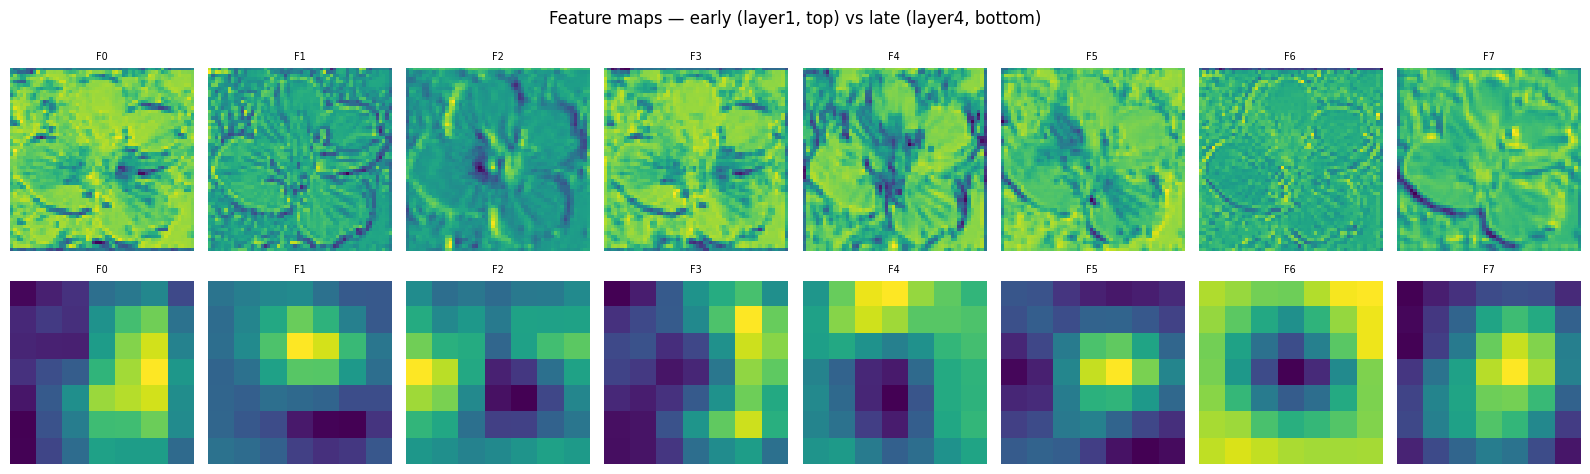

In [11]:
def get_feature_maps(model, image_tensor, layer):
    maps = {}
    def hook(module, inp, out):
        maps['out'] = out.detach().cpu()
    h = layer.register_forward_hook(hook)
    model.eval()
    with torch.no_grad():
        model(image_tensor.unsqueeze(0).to(DEVICE))
    h.remove()
    return maps['out'][0]

best_model = results['B']['model']
sample_img, _ = val_dataset[0]
early_maps = get_feature_maps(best_model, sample_img, best_model.layer1[0].conv1)
late_maps  = get_feature_maps(best_model, sample_img, best_model.layer4[1].conv2)
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Feature maps — early (layer1, top) vs late (layer4, bottom)',fontsize=12)
for i, ax in enumerate(axes[0]):
    ax.imshow(early_maps[i], cmap='viridis')
    ax.axis('off')
    ax.set_title(f'F{i}', fontsize=7)
for i, ax in enumerate(axes[1]):
    ax.imshow(late_maps[i], cmap='viridis')
    ax.axis('off')
    ax.set_title(f'F{i}', fontsize=7)
plt.tight_layout()
plt.savefig('fig_feature_maps.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. Diagnosing and fixing over-fitting

In [12]:

def train_model_custom(model, strategy, num_epochs=20, weight_decay=0.0):
    optimizer = optim.Adam([
        {'params': model.fc.parameters(),     'lr': 1e-3},{'params': model.layer4.parameters(), 'lr': 1e-4},{'params': list(model.layer3.parameters()) +
        list(model.layer2.parameters()) +list(model.layer1.parameters()), 'lr': 1e-5},], weight_decay=weight_decay)

    scheduler = StepLR(optimizer, step_size=7, gamma=0.1)
    criterion = nn.CrossEntropyLoss()

    history = {'train_acc': [], 'val_acc': [],
               'train_loss': [], 'val_loss': []}
    best_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in tqdm(range(num_epochs), desc=f'Strategy {strategy} regularised'):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion)
        scheduler.step()

        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)

        if vl_acc > best_acc:
            best_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    print(f'Best val accuracy: {best_acc:.4f}')
    return model, history

In [13]:
def build_model_regularised(num_classes=NUM_CLASSES):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes))
    return model.to(DEVICE)



model_reg, history_reg = train_model_custom(
    build_model_regularised(),
    strategy='C', num_epochs=NUM_EPOCHS, weight_decay=1e-4)

Strategy C regularised:   0%|          | 0/20 [00:00<?, ?it/s]

Best val accuracy: 0.9078


In [14]:
orig_best = max(results['C']['history']['val_acc'])
reg_best  = max(history_reg['val_acc'])

print(f'\n{"─"*45}')
print(f'{"":25} {"Val Acc":>10}')
print(f'{"─"*45}')
print(f'{"Original Strategy C":25} {orig_best:>10.4f}')
print(f'{"Regularised Strategy C":25} {reg_best:>10.4f}')
print(f'{"Difference":25} {reg_best - orig_best:>+10.4f}')
print(f'{"─"*45}')


─────────────────────────────────────────────
                             Val Acc
─────────────────────────────────────────────
Original Strategy C           0.9216
Regularised Strategy C        0.9078
Difference                   -0.0137
─────────────────────────────────────────────


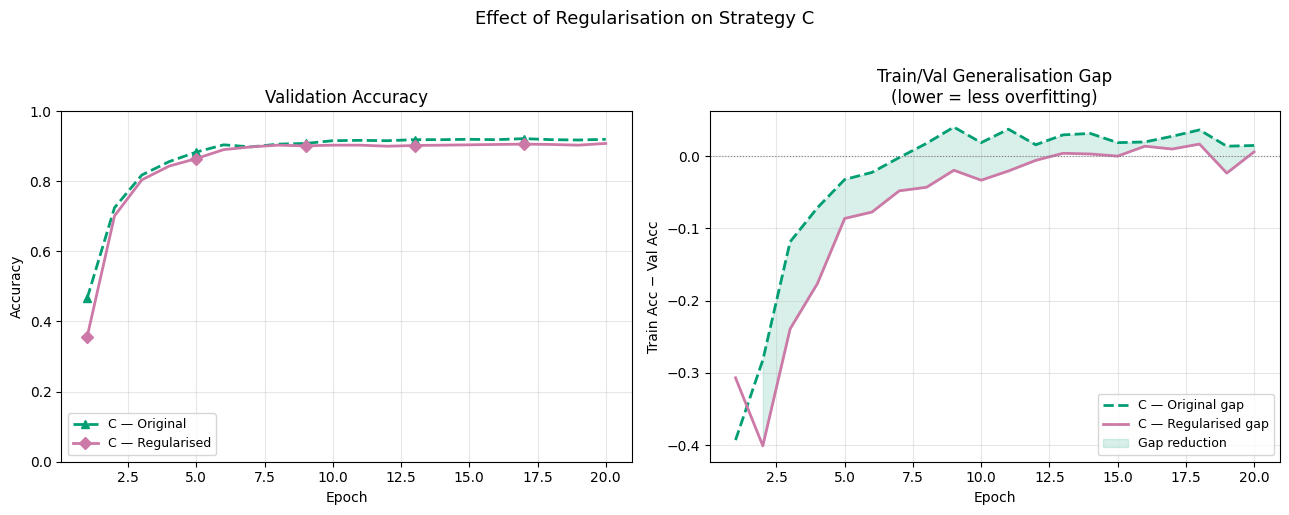

In [15]:
import os
os.makedirs('figures', exist_ok=True)
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(epochs, results['C']['history']['val_acc'],
             color='#009E73', linestyle='--', marker='^',
             markevery=4, linewidth=2, label='C — Original')
axes[0].plot(epochs, history_reg['val_acc'],
             color='#CC79A7', linestyle='-', marker='D',
             markevery=4, linewidth=2, label='C — Regularised')
axes[0].set_title('Validation Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)


gap_orig = [tr - vl for tr, vl in zip(results['C']['history']['train_acc'], results['C']['history']['val_acc'])]
gap_reg  = [tr - vl for tr, vl in zip(history_reg['train_acc'],history_reg['val_acc'])]

axes[1].plot(epochs, gap_orig, color='#009E73', linestyle='--',linewidth=2, label='C — Original gap')
axes[1].plot(epochs, gap_reg,  color='#CC79A7', linestyle='-',linewidth=2, label='C — Regularised gap')
axes[1].axhline(0, color='grey', linewidth=0.8, linestyle=':')
axes[1].fill_between(epochs, gap_orig, gap_reg,where=[o > r for o, r in zip(gap_orig, gap_reg)],alpha=0.15, color='#009E73', label='Gap reduction')
axes[1].set_title('Train/Val Generalisation Gap\n(lower = less overfitting)', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Train Acc − Val Acc')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
plt.suptitle('Effect of Regularisation on Strategy C', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_regularisation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save trained models


In [16]:
os.makedirs('saved_models', exist_ok=True)
for strat in ['A', 'B', 'C']:
    path = f'saved_models/resnet18_strategy_{strat}.pth'
    torch.save(results[strat]['model'].state_dict(), path)
    print(f'Saved: {path}')


Saved: saved_models/resnet18_strategy_A.pth
Saved: saved_models/resnet18_strategy_B.pth
Saved: saved_models/resnet18_strategy_C.pth
